We are tasked with finding a business case to perform exploratory data analysis. I've chosen to use Craigslist Used car data from Kaggle to explore how factors effect price. I want to identify which vehicle features i.e. (age, mileage, brand) most influence price. Here's the link to the Used Car data from Kaggle: https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data

In [ ]:
import kagglehub
import pandas as pd
# Download latest version
path = kagglehub.dataset_download("austinreese/craigslist-carstrucks-data")

print("Path to dataset files:", path)

#load the data into pandas
df_cars = pd.read_csv("/kaggle/input/craigslist-carstrucks-data/vehicles.csv")
df_cars.head(5)


Path to dataset files: /kaggle/input/craigslist-carstrucks-data


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [ ]:
#preview the data features
df_cars.info()
#find number of rows with null values
df_cars.isnull().sum() #there are lots of null values throughout the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

,0
id,0
url,0
region,0
region_url,0
price,0
year,1205
manufacturer,17646
model,5277
condition,174104
cylinders,177678


In [ ]:
#impute mean for numerical datatypes and mode for strings
num_cols = df_cars.select_dtypes(include=['int64','float64']).columns
df_cars[num_cols] = df_cars[num_cols].fillna(df_cars[num_cols].mean())
df_cars = df_cars.drop(columns=['county'])
#impute mode for object datatypes
#loop over object datatype
for col in df_cars.select_dtypes(include='object').columns:
    #calculate mode for each column
    mode_val = df_cars[col].mode()[0]
    df_cars[col] = df_cars[col].fillna(mode_val)

df_cars.isnull().sum()

,0
id,0
url,0
region,0
region_url,0
price,0
year,0
manufacturer,0
model,0
condition,0
cylinders,0


In [ ]:
#find the number of rows with duplicate values
df_cars.duplicated().sum() #no duplicated rows across all columns

np.int64(0)

In [ ]:
#loop over col to find number of duplicates
for col in df_cars.columns:
  print(f"Column:{col}")
  print("Duplicates:",df_cars[col].duplicated().sum())

Column:id
Duplicates: 0
Column:url
Duplicates: 0
Column:region
Duplicates: 426476
Column:region_url
Duplicates: 426467
Column:price
Duplicates: 411225
Column:year
Duplicates: 426765
Column:manufacturer
Duplicates: 426838
Column:model
Duplicates: 397213
Column:condition
Duplicates: 426874
Column:cylinders
Duplicates: 426872
Column:fuel
Duplicates: 426875
Column:odometer
Duplicates: 322009
Column:title_status
Duplicates: 426874
Column:transmission
Duplicates: 426877
Column:VIN
Duplicates: 308616
Column:drive
Duplicates: 426877
Column:size
Duplicates: 426876
Column:type
Duplicates: 426867
Column:paint_color
Duplicates: 426868
Column:image_url
Duplicates: 184981
Column:description
Duplicates: 65969
Column:state
Duplicates: 426829
Column:lat
Duplicates: 373698
Column:long
Duplicates: 373107
Column:posting_date
Duplicates: 45344


In [ ]:
#ID, URL, VIN should have no duplicates. So drop VIN duplicates
df_cars= df_cars.drop_duplicates(subset="VIN", keep='first')
df_cars['VIN'].duplicated().sum()

np.int64(0)

In [ ]:
#check for erroneous values
#drop columns with naturally messy data
exclude_cat = ['description','url','image_url','posting_date','VIN','region_url']
df_filtered=df_cars.drop(columns=exclude_cat)
#loop over each column counting unique values
categories = list(df_filtered.select_dtypes(include=['object']).columns)

for column in categories:
    print(column)
    print(df_filtered[[column]].value_counts())# There are no obvious erroneous values after duplicates and null values were dropped


region
region          
seattle-tacoma      1963
portland            1850
des moines          1581
boise               1490
inland empire       1484
                    ... 
kokomo                 1
owensboro              1
southwest VA           1
southwest MS           1
twin tiers NY/PA       1
Name: count, Length: 400, dtype: int64
manufacturer
manufacturer   
ford               21864
chevrolet          14057
toyota             10286
honda               6742
nissan              6095
jeep                5589
ram                 4622
gmc                 4353
bmw                 4129
dodge               3762
hyundai             3518
mercedes-benz       3402
subaru              3351
kia                 3008
volkswagen          2706
lexus               2366
audi                2115
cadillac            1921
chrysler            1834
mazda               1630
buick               1514
acura               1454
infiniti            1289
lincoln              998
volvo                877
mitsubis

In [ ]:
#check for outliers
#create a function to calculate inner quartile range

def iqr_outliers(df,column):
  q1= df[column].quantile(.25)
  q3=df[column].quantile(.75)

  iqr=q3-q1
#calculate outliers
  lower_threshold=q1 -1.5*iqr
  upper_threshold=q3+1.5*iqr
  outliers = (df[column] < lower_threshold) | (df[column] > upper_threshold)
  #count number of outliers
  return outliers.sum()


In [ ]:
#select numerical dataype columns
num_var = list(df_cars.select_dtypes(include =['int64','float64']).columns)
#print the outliers in each numerical category by calling the function
for column in num_var:
    print(f'{column}: {iqr_outliers(df_cars,column)}') # year and price have unusually high number of outliers

id: 1
price: 3542
year: 3120
odometer: 1047
lat: 2740
long: 46


In [ ]:
#windsorize the outliers
num_var = list(df_cars.select_dtypes(include =['int64','float64']).columns)
for column in num_var:
  #convert columns to float because colab gave warning
  df_cars.loc[:,column] = df_cars[column].astype(float)
  high_pct_value = df_cars[column].quantile(.95)
  #clip upper outliers
  df_cars.loc[:,column] = df_cars[column].clip(upper=high_pct_value)
  #set clipping threshold
  low_pct_value = df_cars[column].quantile(.05)
  #clip outliers
  df_cars.loc[:,column] = df_cars[column].clip(lower=low_pct_value)

/tmp/ipython-input-10-4151054.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[7.22269592e+09 7.31680143e+09 7.31680143e+09 ... 7.30436005e+09
 7.30372315e+09 7.30233838e+09]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_cars.loc[:,column] = df_cars[column].clip(upper=high_pct_value)


In [ ]:
#filter the data to ony include numerical values and generate descriptive stats
df_car_num= df_cars.select_dtypes(include=['int64','float64'])
#drop id, longitude and latitude for stats
df_car_num.drop(['id','long','lat','id'], axis = 1,inplace=True)
df_car_num.describe()

,price,year,odometer
count,118264.000000,118264.000000,118264.000000
mean,15929.261610,2013.117015,87571.404977
std,12643.077919,4.841266,53164.964579
min,0.000000,2003.000000,8841.150000
25%,6000.000000,2010.000000,40767.500000
50%,13222.000000,2014.000000,85552.500000
75%,23988.000000,2017.000000,125997.000000
max,43999.000000,2020.000000,191432.700000


In [ ]:
#find correlation coefficients for used car variables
df_car_num.corr()
#We can see price and year have a strong postive correlation and price and odometer have negative correlation

,price,year,odometer
price,1.000000,0.413308,-0.397910
year,0.413308,1.000000,-0.643068
odometer,-0.397910,-0.643068,1.000000


In [ ]:
#select columns to group and compare average price
grouped_cols = ['manufacturer','condition','state','paint_color','cylinders','type','drive','size','fuel','title_status']

for col in grouped_cols:
  print(f"\nAverage Price by {col}:")
  #group by column and find average price
  print(df_cars.groupby(col)['price'].mean().sort_values (ascending=False).round())
# we can see manufacturer and condition are very influential in determining price


Average Price by manufacturer:
manufacturer
tesla              33872.0
ferrari            32774.0
porsche            27880.0
aston-martin       27031.0
alfa-romeo         25969.0
rover              25373.0
ram                24463.0
gmc                20773.0
jaguar             19975.0
audi               19296.0
mercedes-benz      18808.0
ford               18055.0
cadillac           17844.0
bmw                17650.0
infiniti           17410.0
lexus              17302.0
jeep               17022.0
datsun             16720.0
lincoln            16611.0
chevrolet          16472.0
volvo              15486.0
acura              15345.0
toyota             14398.0
dodge              14090.0
subaru             13689.0
buick              12906.0
mini               12249.0
volkswagen         11995.0
mitsubishi         11884.0
nissan             11711.0
harley-davidson    11475.0
kia                11195.0
honda              11006.0
hyundai            10653.0
mazda              10578.0
chrysler  

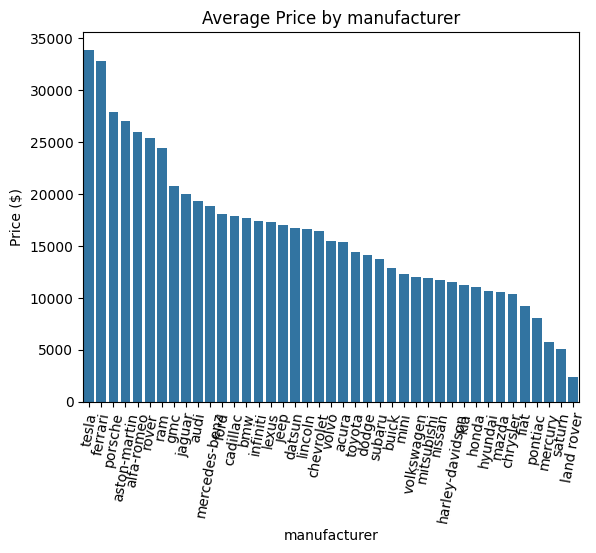

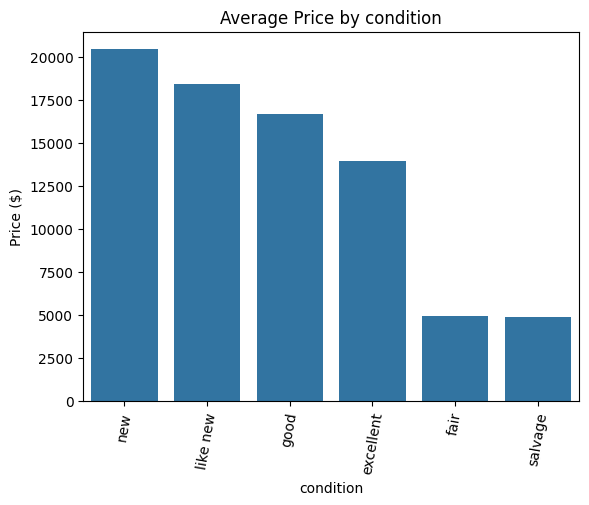

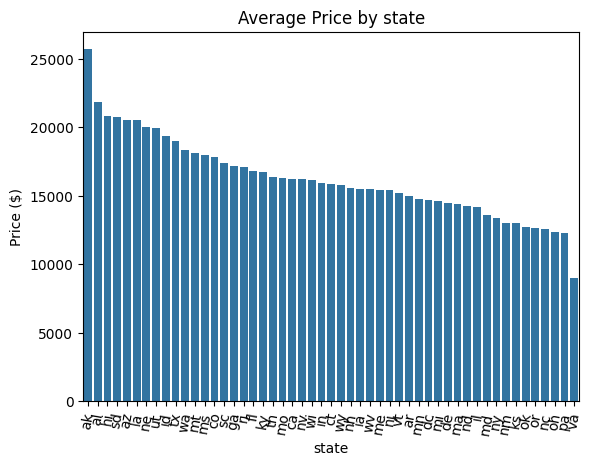

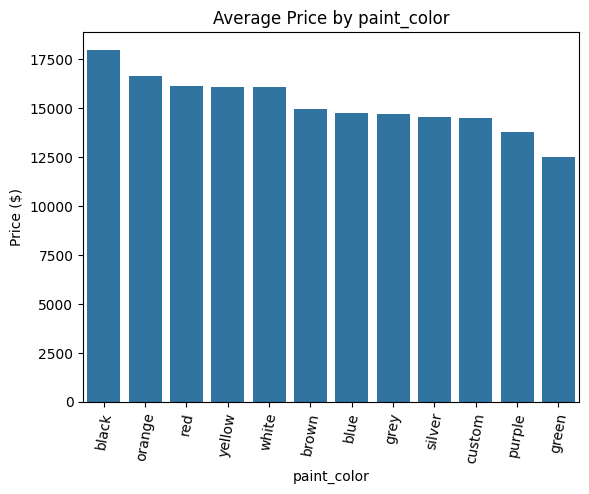

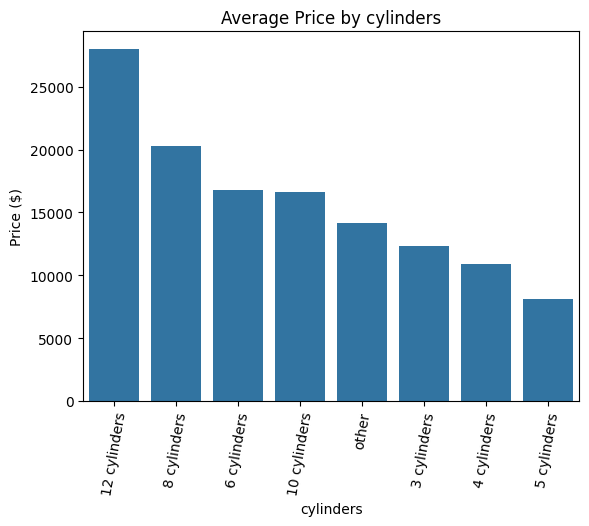

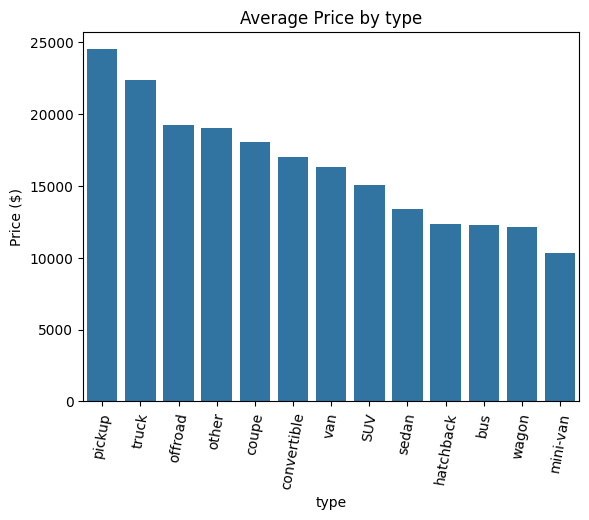

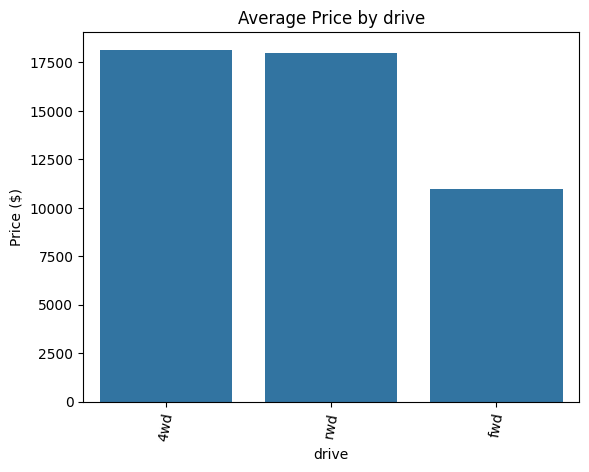

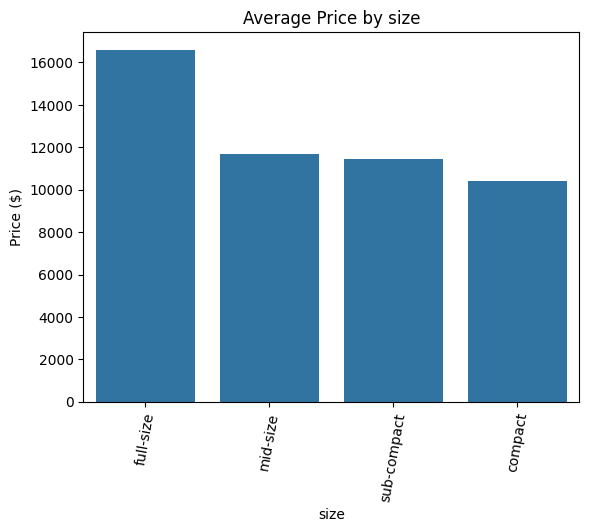

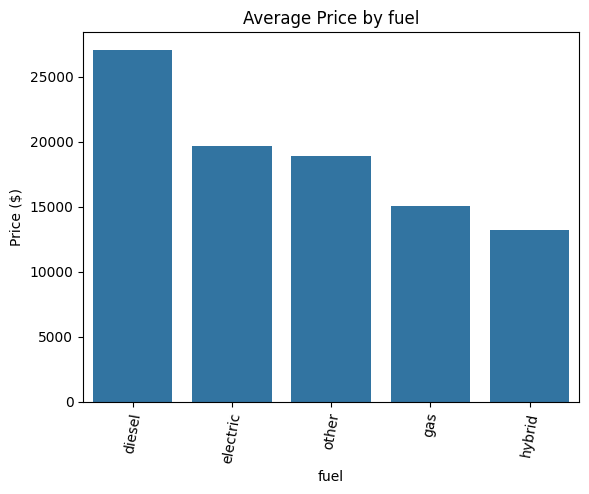

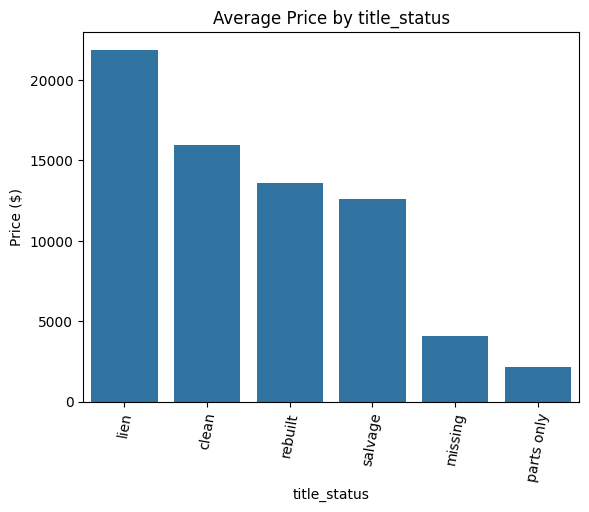

In [ ]:
#create bar charts to vizualize average by for the grouped categories
import seaborn as sns
import matplotlib.pyplot as plt

grouped_cols = ['manufacturer','condition','state','paint_color','cylinders','type','drive','size','fuel','title_status']
#loop over the grouped columns and create a bar plot for each group
for col in grouped_cols:
#find average price and group the columns
    avg_price = df_cars.groupby(col)['price'].mean().sort_values(ascending=False).reset_index()

    sns.barplot(data=avg_price, x=col, y='price')
#plot labels
    plt.title(f'Average Price by {col}')
    plt.xlabel(col)
    plt.xticks(rotation=80)
    plt.ylabel('Price ($)')
    plt.show()
